First 5 rows of the dataset:
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121

Missing values in the dataset:
Passengers    0
dtype: int64


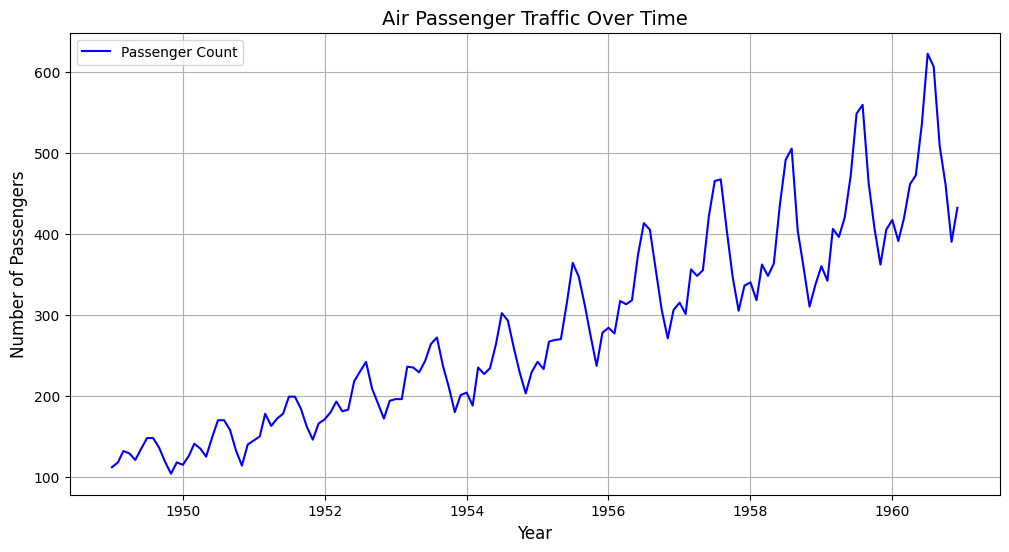

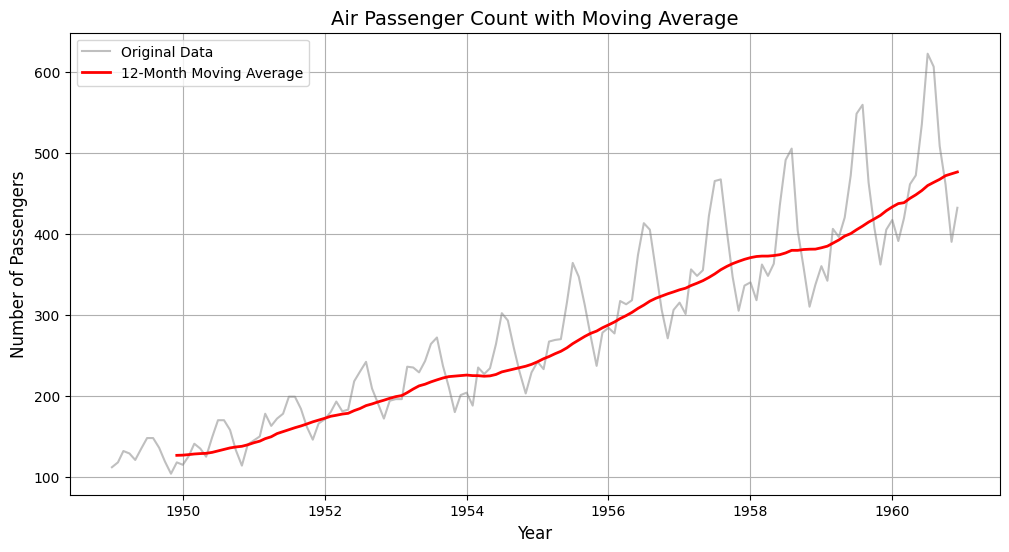

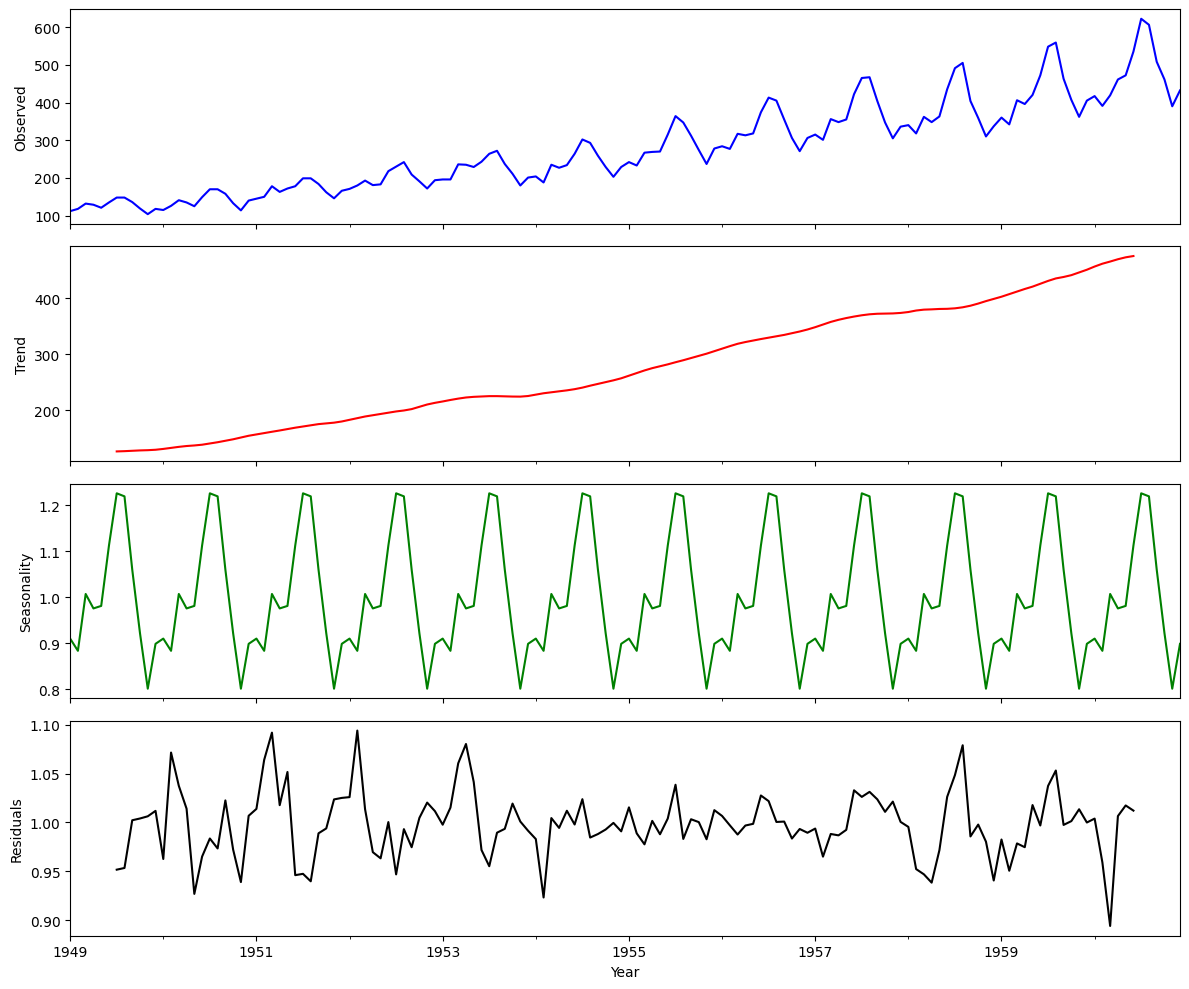

<ipython-input-4-90ac2182d717>:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Month_Num'], y=df['Passengers'], palette="coolwarm")


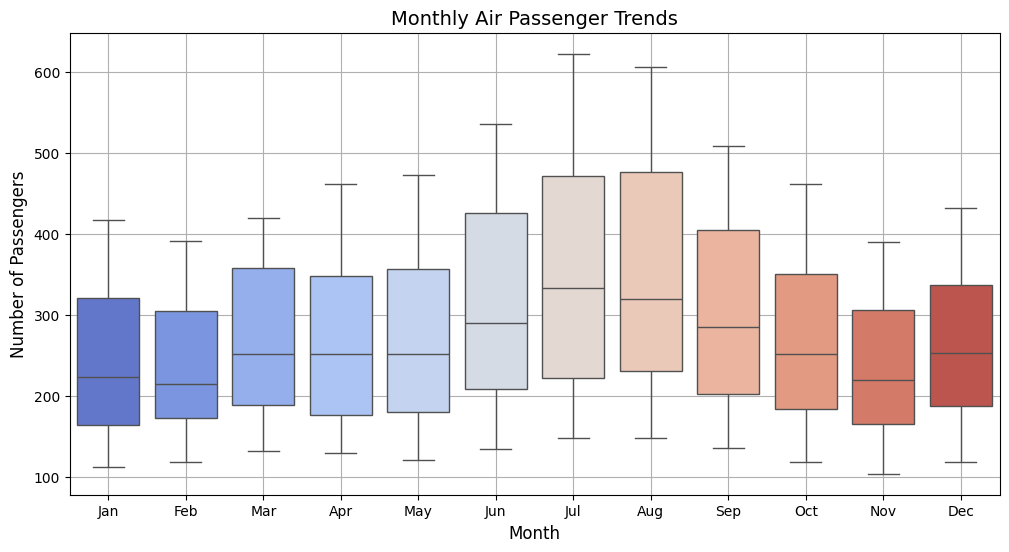

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the dataset (Update the file path if necessary)
file_path = "/content/AirPassengers.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

# Convert 'Month' column to datetime format
df['Month'] = pd.to_datetime(df['Month'])

# Set 'Month' as index for time series analysis
df.set_index('Month', inplace=True)

# Rename columns if needed
df.columns = ['Passengers']

# Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Plot the time series data
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=df['Passengers'], color="b", label="Passenger Count")
plt.title("Air Passenger Traffic Over Time", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# Rolling average to visualize trends (Moving Average)
df['Moving_Avg'] = df['Passengers'].rolling(window=12).mean()

# Plot the moving average trend
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label="Original Data", color='gray', alpha=0.5)
plt.plot(df.index, df['Moving_Avg'], label="12-Month Moving Average", color='red', linewidth=2)
plt.title("Air Passenger Count with Moving Average", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Seasonal decomposition (Trend, Seasonal, Residual)
decomposition = sm.tsa.seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], legend=False, color="blue")
axes[0].set_ylabel("Observed")
decomposition.trend.plot(ax=axes[1], legend=False, color="red")
axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], legend=False, color="green")
axes[2].set_ylabel("Seasonality")
decomposition.resid.plot(ax=axes[3], legend=False, color="black")
axes[3].set_ylabel("Residuals")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

# Boxplot for monthly trends
df['Month_Num'] = df.index.month
df['Year'] = df.index.year

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Month_Num'], y=df['Passengers'], palette="coolwarm")
plt.title("Monthly Air Passenger Trends", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks(ticks=range(12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)
plt.show()
